## 1. Simple Linear Regression

Regresi linear sederhana memodelkan hubungan satu predictor `X` dengan response `Y`.

$$Y_i=b_0+b_1X_i+e_i$$

Fitted value:
$$\hat Y_i=\hat b_0+\hat b_1X_i$$

Residual:
$$e_i=Y_i-\hat Y_i$$

Regresi dapat digunakan untuk prediction maupun explanation. Persamaan regresi sendiri tidak membuktikan causation.

## 2. Regression Equation

Intercept adalah prediksi Y saat X=0. Slope menunjukkan perubahan prediksi Y untuk kenaikan satu unit X. Interpretasi selalu bergantung pada satuan variabel.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import files
uploaded = files.upload()

Saving house_sales.csv to house_sales.csv


In [2]:
lung = pd.read_csv('LungDisease.csv')
predictors = ['Exposure']
outcome = 'PEFR'
model = LinearRegression()
model.fit(lung[predictors], lung[outcome])
print(f'Intercept: {model.intercept_:.3f}')
print(f'Coefficient Exposure: {model.coef_[0]:.3f}')

Intercept: 424.583
Coefficient Exposure: -4.185


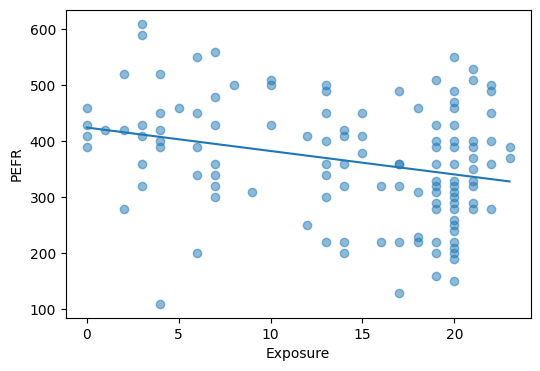

In [3]:
fitted = model.predict(lung[predictors])
residuals = lung[outcome] - fitted
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(lung['Exposure'], lung['PEFR'], alpha=0.5)
x=np.linspace(lung['Exposure'].min(), lung['Exposure'].max(),100)
y=model.predict(pd.DataFrame({'Exposure':x}))
ax.plot(x,y)
ax.set_xlabel('Exposure'); ax.set_ylabel('PEFR')
plt.show()

## 3. Fitted Values and Residuals

Fitted values adalah prediksi model. Residual adalah error prediksi. Residual positif berarti nilai aktual berada di atas prediksi; residual negatif berarti aktual berada di bawah prediksi.

In [4]:
pd.DataFrame({'Actual': lung[outcome], 'Fitted': fitted, 'Residual': residuals}).head()

,Actual,Fitted,Residual
0,390,424.582807,-34.582807
1,410,424.582807,-14.582807
2,430,424.582807,5.417193
3,460,424.582807,35.417193
4,420,420.398230,-0.398230


## 4. Least Squares

OLS memilih koefisien yang meminimalkan **Residual Sum of Squares (RSS)**:

$$RSS=\sum_{i=1}^{n}(Y_i-\hat Y_i)^2$$

Metode ini disebut least squares regression.

In [5]:
rss=np.sum((lung[outcome]-fitted)**2)
print(f'RSS: {rss:.3f}')

RSS: 1234764.286


## 5. Prediction Versus Explanation

Prediction berfokus pada kemampuan model memprediksi data baru. Explanation/profiling berfokus pada hubungan antarvariabel dan interpretasi koefisien. Model regresi tidak dengan sendirinya menetapkan arah sebab-akibat.

## 6. Multiple Linear Regression

Dengan beberapa predictor:

$$Y=b_0+b_1X_1+b_2X_2+\cdots+b_pX_p+e$$

Koefisien $b_j$ diinterpretasikan sebagai perubahan prediksi Y untuk kenaikan satu unit $X_j$, dengan predictor lain tetap.

## 7. Example: King County Housing Data

Response: `AdjSalePrice`. Predictors: `SqFtTotLiving`, `SqFtLot`, `Bathrooms`, `Bedrooms`, `BldgGrade`. Tujuan utamanya adalah memprediksi harga penjualan rumah.

In [11]:
house = pd.read_csv('house_sales.csv', sep='\t')
subset=['AdjSalePrice','SqFtTotLiving','SqFtLot','Bathrooms','Bedrooms','BldgGrade']
house[subset].head()

,AdjSalePrice,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade
1,300805.0,2400,9373,3.00,6,7
2,1076162.0,3764,20156,3.75,4,10
3,761805.0,2060,26036,1.75,4,8
4,442065.0,3200,8618,3.75,5,7
5,297065.0,1720,8620,1.75,4,7


In [12]:
predictors=['SqFtTotLiving','SqFtLot','Bathrooms','Bedrooms','BldgGrade']
outcome='AdjSalePrice'
house_lm=LinearRegression()
house_lm.fit(house[predictors],house[outcome])
print(f'Intercept: {house_lm.intercept_:.3f}')
print('Coefficients:')
for name,coef in zip(predictors,house_lm.coef_): print(f' {name}: {coef}')

Intercept: -521871.368
Coefficients:
 SqFtTotLiving: 228.83060360240793
 SqFtLot: -0.06046682065307607
 Bathrooms: -19442.840398321066
 Bedrooms: -47769.95518521438
 BldgGrade: 106106.96307898081


Pada data contoh, koefisien `SqFtTotLiving` sekitar 228.8. Dengan predictor lain tetap, tambahan satu square foot ruang tinggal diperkirakan menaikkan nilai sekitar 229; 1.000 square feet sekitar 228.800.

## 8. Assessing the Model

**RMSE**:
$$RMSE=\sqrt{\frac{\sum(Y_i-\hat Y_i)^2}{n}}$$

**RSE** untuk p predictor:
$$RSE=\sqrt{\frac{\sum(Y_i-\hat Y_i)^2}{n-p-1}}$$

**R-squared**:
$$R^2=1-\frac{RSS}{TSS}$$

RMSE/RSE mengukur besar error dalam satuan response; R² menunjukkan proporsi variasi response yang dijelaskan model.

In [13]:
pred=house_lm.predict(house[predictors])
rmse=np.sqrt(mean_squared_error(house[outcome],pred))
r2=r2_score(house[outcome],pred)
n=len(house); p=len(predictors)
rse=np.sqrt(np.sum((house[outcome]-pred)**2)/(n-p-1))
print(f'RMSE: {rmse:.3f}')
print(f'RSE: {rse:.3f}')
print(f'R-squared: {r2:.4f}')

RMSE: 261220.197
RSE: 261254.747
R-squared: 0.5406


## 9. Cross-Validation

K-fold cross-validation membagi data menjadi k bagian, melatih model pada k-1 bagian dan mengevaluasi pada bagian yang tersisa. Proses diulang sampai semua bagian menjadi validation set. Ini membantu menilai performa pada data baru dan mendeteksi overfitting.

In [14]:
from sklearn.model_selection import KFold, cross_val_score
kfold=KFold(n_splits=5,shuffle=True,random_state=1)
cv_rmse=np.sqrt(-cross_val_score(LinearRegression(),house[predictors],house[outcome],scoring='neg_mean_squared_error',cv=kfold))
print('RMSE per fold:',cv_rmse)
print('Mean CV RMSE:',cv_rmse.mean())

RMSE per fold: [246891.84102191 288346.79849715 256308.30381001 270674.09018667
 242404.42803775]
Mean CV RMSE: 260925.09231069806


## 10. Model Selection and Stepwise Regression

Model selection mencari keseimbangan antara fit dan kompleksitas. Pendekatan yang dibahas meliputi all-subset, forward selection, backward elimination, stepwise selection, serta penalized regression seperti ridge dan lasso.

Forward selection dimulai dari tanpa predictor dan menambah predictor secara bertahap. Backward elimination dimulai dari full model dan menghapus predictor. Stepwise menggabungkan ide tersebut. Cross-validation dapat digunakan untuk memeriksa performa model terpilih pada data baru.

In [15]:
formula_full='AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + Bedrooms + BldgGrade'
model_full=smf.ols(formula=formula_full,data=house).fit()
print('AIC full model:',model_full.aic)

AIC full model: 630350.2184643305


## 11. Weighted Regression

Weighted regression memberi bobot berbeda pada observasi. Contoh penggunaan: observasi dengan precision berbeda atau satu baris mewakili jumlah kasus yang berbeda. Pada housing example, bobot dapat dibentuk dari tahun transaksi.

In [16]:
house['Year']=[int(date.split('-')[0]) for date in house.DocumentDate]
house['Weight']=house.Year-2005
house_wt=LinearRegression()
house_wt.fit(house[predictors],house[outcome],sample_weight=house.Weight)
print(f'Intercept: {house_wt.intercept_:.3f}')
for name,coef in zip(predictors,house_wt.coef_): print(f' {name}: {coef}')

Intercept: -584189.329
 SqFtTotLiving: 245.02408862720128
 SqFtLot: -0.292414748005541
 Bathrooms: -26085.97010861501
 Bedrooms: -53608.876436313745
 BldgGrade: 115242.43472609237


## 12. Prediction Using Regression

Regression digunakan untuk menghasilkan prediksi observasi baru. **Prediction interval** adalah interval ketidakpastian untuk nilai individual yang diprediksi.

In [17]:
new_house=pd.DataFrame({'SqFtTotLiving':[2000],'SqFtLot':[5000],'Bathrooms':[2.5],'Bedrooms':[3],'BldgGrade':[8]})
print(f'Predicted price: {house_lm.predict(new_house)[0]:.2f}')

Predicted price: 592426.24


## 13. The Dangers of Extrapolation

Extrapolation berarti memakai model di luar range predictor yang tersedia pada data training. Model sebaiknya digunakan pada kondisi yang memiliki dukungan data yang memadai. Prediksi di luar range dapat menghasilkan nilai yang tidak masuk akal.

In [18]:
for col in predictors: print(f'{col}: {house[col].min()} to {house[col].max()}')

SqFtTotLiving: 370 to 10740
SqFtLot: 494 to 1024068
Bathrooms: 0.0 to 8.0
Bedrooms: 0 to 33
BldgGrade: 3 to 13


## 14. Confidence and Prediction Intervals

Confidence interval dapat dibangun untuk parameter regresi. Salah satu pendekatan adalah bootstrap: resample baris dengan replacement, fit model, simpan koefisien, ulangi banyak kali, lalu ambil percentile koefisien.

In [23]:
rng=np.random.default_rng(1)
B=500
coef_boot=[]
for _ in range(B):
    idx=rng.integers(0,len(house),len(house)); sample=house.iloc[idx]
    m=LinearRegression(); m.fit(sample[predictors],sample[outcome])
    coef_boot.append(np.r_[m.intercept_,m.coef_])
coef_boot=np.array(coef_boot)
names=['Intercept']+predictors
pd.DataFrame({'2.5%':np.percentile(coef_boot,2.5,axis=0),'50%':np.percentile(coef_boot,50,axis=0),'97.5%':np.percentile(coef_boot,97.5,axis=0)},index=names)

,2.5%,50%,97.5%
Intercept,-574251.910975,-521651.544714,-469870.730232
SqFtTotLiving,207.797004,228.210177,250.776767
SqFtLot,-0.226977,-0.059418,0.132231
Bathrooms,-28086.418632,-19276.016746,-9591.298192
Bedrooms,-58766.340789,-48252.618872,-36957.924839
BldgGrade,98771.497604,106360.171911,113738.949286


## 15. Factor Variables and Dummy Variables

Predictor kategorikal perlu direpresentasikan sebagai variabel numerik. Jika terdapat P kategori dan model memiliki intercept, biasanya digunakan P-1 dummy variables dengan satu kategori sebagai reference. `drop_first=True` digunakan untuk menghindari redundansi/multicollinearity.

In [24]:
house['PropertyType'].head()
pd.get_dummies(house['PropertyType']).head()
pd.get_dummies(house['PropertyType'],drop_first=True).head()

,Single Family,Townhouse
1,False,False
2,True,False
3,True,False
4,True,False
5,True,False


In [25]:
predictors_factor=['SqFtTotLiving','SqFtLot','Bathrooms','Bedrooms','BldgGrade','PropertyType']
X_factor=pd.get_dummies(house[predictors_factor],drop_first=True)
house_lm_factor=LinearRegression(); house_lm_factor.fit(X_factor,house[outcome])
print(f'Intercept: {house_lm_factor.intercept_:.3f}')
for name,coef in zip(X_factor.columns,house_lm_factor.coef_): print(f' {name}: {coef}')

Intercept: -446841.366
 SqFtTotLiving: 223.37362892503828
 SqFtLot: -0.07036798136813083
 Bathrooms: -15979.013473415205
 Bedrooms: -50889.73218483025
 BldgGrade: 109416.30516146179
 PropertyType_Single Family: -84678.21629549257
 PropertyType_Townhouse: -115121.97921609184


## 16. Interpreting the Regression Equation

Koefisien adalah conditional effect dalam model: perubahan predictor diinterpretasikan dengan predictor lain dianggap tetap. Karena predictor dapat saling berkorelasi, koefisien tidak selalu dapat dibaca sebagai hubungan sebab-akibat.

## 17. Correlated Predictors, Multicollinearity, and Confounding

**Multicollinearity** terjadi ketika predictor sangat berkorelasi atau memiliki redundansi linear. Perfect multicollinearity membuat solusi regresi tidak terdefinisi secara unik; nonperfect multicollinearity dapat membuat koefisien tidak stabil.

**Confounding** terjadi ketika variabel penting tidak dimasukkan sehingga hubungan predictor-response tercampur dengan pengaruh variabel tersebut.

In [26]:
house[predictors].corr()

,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade
SqFtTotLiving,1.000000,0.195967,0.764155,0.600317,0.770499
SqFtLot,0.195967,1.000000,0.107439,0.069091,0.145508
Bathrooms,0.764155,0.107439,1.000000,0.537998,0.658738
Bedrooms,0.600317,0.069091,0.537998,1.000000,0.368125
BldgGrade,0.770499,0.145508,0.658738,0.368125,1.000000


## 18. Interactions and Main Effects

Model main effects mengasumsikan hubungan predictor dengan response tidak bergantung pada predictor lain. Jika hubungan bersifat interdependen, interaction term dapat digunakan:

$$Y=b_0+b_1X+b_2Z+b_3XZ+e$$

Pada housing data, hubungan ukuran rumah dan harga dapat berbeda berdasarkan kelompok lokasi.

In [ ]:
if 'ZipGroup' in house.columns:
    interaction_model=smf.ols('AdjSalePrice ~ SqFtTotLiving * ZipGroup + SqFtLot + Bathrooms + Bedrooms + BldgGrade + PropertyType',data=house).fit()
    print(interaction_model.summary())
else:
    print('Kolom ZipGroup tidak tersedia pada dataset.')

## 19. Regression Diagnostics

Diagnostics meliputi standardized residuals, outliers, influential values, leverage/hat-values, Cook's distance, heteroskedasticity, non-normality, correlated errors, dan partial residual plots.

Outlier regresi adalah observasi dengan response jauh dari prediksi. Influential observation adalah observasi yang kehadiran/ketidakhadirannya mengubah persamaan regresi secara berarti.

In [29]:
if 'ZipCode' in house.columns:
    house_98105=house.loc[house['ZipCode']==98105,:].copy()
    X98105=sm.add_constant(house_98105[predictors])
    result_98105=sm.OLS(house_98105[outcome],X98105).fit()
    from statsmodels.stats.outliers_influence import OLSInfluence
    influence=OLSInfluence(result_98105)
    sresiduals=influence.resid_studentized_internal
    print('Minimum studentized residual:',sresiduals.min())

Minimum studentized residual: -4.326731804078571


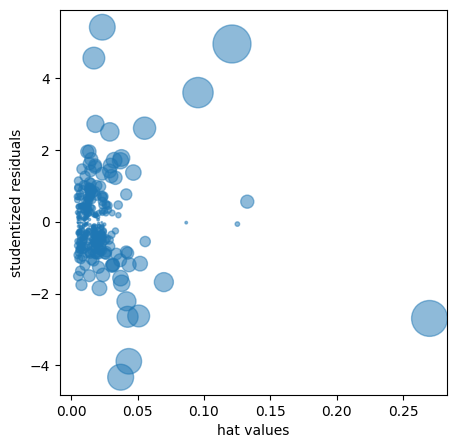

In [30]:
if 'ZipCode' in house.columns:
    fig,ax=plt.subplots(figsize=(5,5))
    ax.scatter(influence.hat_matrix_diag,influence.resid_studentized_internal,s=1000*np.sqrt(influence.cooks_distance[0]),alpha=.5)
    ax.set_xlabel('hat values'); ax.set_ylabel('studentized residuals'); plt.show()

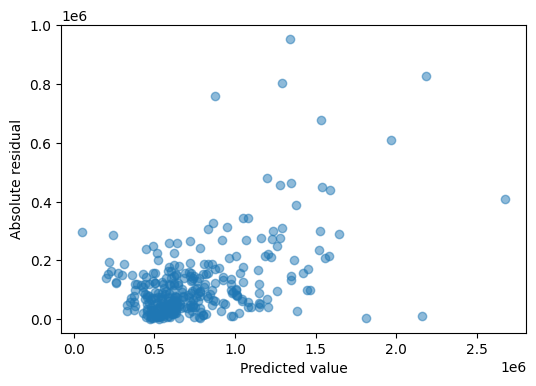

In [31]:
if 'ZipCode' in house.columns:
    pred98105=result_98105.fittedvalues; resid98105=result_98105.resid
    fig,ax=plt.subplots(figsize=(6,4)); ax.scatter(pred98105,np.abs(resid98105),alpha=.5)
    ax.set_xlabel('Predicted value'); ax.set_ylabel('Absolute residual'); plt.show()

## 20. Partial Residual Plots and Nonlinearity

Partial residual plot mengisolasi hubungan satu predictor dengan response setelah memperhitungkan predictor lain.

$$Partial\ residual=Residual+\hat b_iX_i$$

Pola curvature menunjukkan bahwa hubungan linear mungkin tidak cukup.

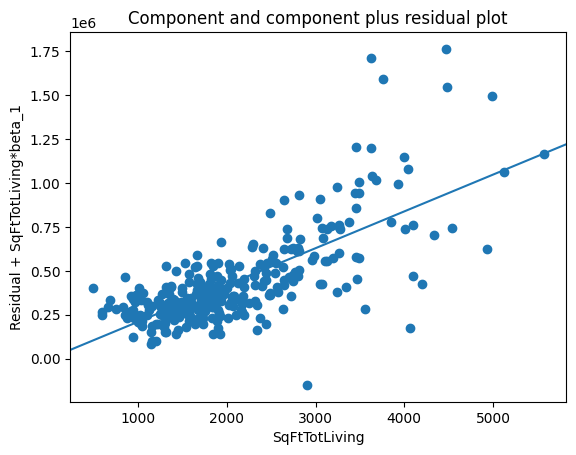

In [32]:
if 'ZipCode' in house.columns:
    sm.graphics.plot_ccpr(result_98105,'SqFtTotLiving')
    plt.show()

## 21. Polynomial Regression

Polynomial regression menambahkan pangkat predictor. Quadratic model:

$$Y=b_0+b_1X+b_2X^2+e$$

Pendekatan ini dapat menangkap curvature.

In [33]:
if 'ZipCode' in house.columns:
    model_poly=smf.ols(formula='AdjSalePrice ~ SqFtTotLiving + I(SqFtTotLiving**2) + SqFtLot + Bathrooms + Bedrooms + BldgGrade',data=house_98105)
    result_poly=model_poly.fit()
    print(result_poly.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     211.6
Date:                Fri, 02 Oct 2026   Prob (F-statistic):          9.95e-106
Time:                        11:49:56   Log-Likelihood:                -4217.9
No. Observations:                 313   AIC:                             8450.
Df Residuals:                     306   BIC:                             8476.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept             -6.159e+

## 22. Spline Regression

Spline memodelkan hubungan nonlinear dengan beberapa segmen polynomial yang tersambung secara smooth. `knots` adalah titik pemisah segmen; degree menentukan derajat polynomial.

In [34]:
if 'ZipCode' in house.columns:
    formula='AdjSalePrice ~ bs(SqFtTotLiving, df=6, degree=3) + SqFtLot + Bathrooms + Bedrooms + BldgGrade'
    model_spline=smf.ols(formula=formula,data=house_98105)
    result_spline=model_spline.fit()
    print(result_spline.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     131.8
Date:                Fri, 02 Oct 2026   Prob (F-statistic):          7.10e-104
Time:                        11:50:14   Log-Likelihood:                -4211.4
No. Observations:                 313   AIC:                             8445.
Df Residuals:                     302   BIC:                             8486.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


## 23. Generalized Additive Models (GAM)

GAM memungkinkan hubungan nonlinear menggunakan smooth functions:

$$Y=\beta_0+f_1(X_1)+f_2(X_2)+\cdots+e$$
